# Minimum fire-size filter on the overlap maps

**Purpose.** Both models drop predicted burn patches smaller than a minimum size
(25 pixels by default) as a clean-up step. We test whether raising that minimum,
from 25 up to 200 pixels, still helps *after* the overlap vote has already removed
some false alarms. We study the 50% overlap run at two voting strictnesses, a
plain majority (50 percent of windows) and a strict vote (75 percent).

**Dataset.** The 50% overlap burned-area maps of tile T29TPG for both Swin-YNet
and EfficientNet-B2 (before 2025-07-07, after 2025-10-15), thresholded at vote 50
and 75 percent, scored against the ICNF fire records filtered to the window and
clipped to Portugal.

**Objectives.** (1) Tabulate the scores for every vote and minimum-size pair;
(2) see how the minimum size changes F1 and MCC; (3) show the precision-recall
trade; (4) track the burned area; (5) map where the filter cleans up.

**Method.** We do not re-run the models. We take the 50% overlap vote map, turn it
into a burned map at each vote threshold, find the connected burned patches on the
full tile, and remove patches below each size threshold (25, 50, ..., 200 pixels;
one pixel is 100 square metres).

## 1. Setup and data

This section loads the overlap vote maps and the ground truth, builds the burned
maps at vote 50 and 75 percent, and labels the burned patches once each so the
size sweep is cheap.

### 1.1 Environment and plotting style

Import the libraries and set one clean style, a colour per model, and a line style
per vote threshold.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.ndimage import label as ndlabel

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 140, "font.size": 11,
    "axes.titlesize": 12, "axes.titleweight": "medium",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
MODEL_COLOR = {"swin_ynet": "#4477aa", "efficientnet_b2": "#cc6677"}
MODEL_LABEL = {"swin_ynet": "Swin-YNet", "efficientnet_b2": "EfficientNet-B2"}
VOTE_LS = {50: "-", 75: "--"}                 # line style per vote threshold
C_AGREE = "#762a83"; C_FALSE = "#d6604d"; C_MISS = "#2c7bb6"

for _c in (Path.cwd(), Path.cwd().parent):
    if (_c / "utils" / "config.py").exists():
        sys.path.insert(0, str(_c)); break
from utils.config import load_config
cfg = load_config()

### 1.2 Load the vote maps and label the burned patches

We use the 50% overlap run. The vote map gives, for each pixel, the percent of
covering windows that voted burned. Turning it into a burned map at vote 50 and 75
percent gives four base maps (two models times two thresholds). We label the
connected burned patches on each one time; every patch keeps its size in pixels.

In [2]:
BEFORE, AFTER = "2025-07-07", "2025-10-15"
B, A = BEFORE.replace("-", ""), AFTER.replace("-", "")
PRED   = cfg.predictions_dir
LABELS = cfg.repo_root / "data/processed/icnf_burned_labels_t29tpg_2025.tif"
ICNF_SHP = cfg.repo_root / "data/shapefiles/ground_truth_ICNF/ardida_2025.shp"
PT_BOUND = cfg.repo_root / "data/shapefiles/boundary_files/portugal_continental_32629.gpkg"
PIX_HA = 0.01
MODELS = ["efficientnet_b2", "swin_ynet"]
OVERLAP = 50                 # study the 50% overlap run
VOTE_PCTS = [50, 75]         # 2 of 4 and 3 of 4 covering windows

def read(p):
    with rasterio.open(p) as r: return r.read(1)

def votes_path(mdl):    return PRED / f"T29TPG_{mdl}_ov{OVERLAP:02d}_{B}_{A}_votes.tif"
def observed_path(mdl): return PRED / f"T29TPG_{mdl}_ov{OVERLAP:02d}_{B}_{A}_observed.tif"

labels_img = read(LABELS)
with rasterio.open(LABELS) as _r:
    GRID_T, GRID_SHAPE = _r.transform, (_r.height, _r.width)
    EXTENT = (_r.bounds.left, _r.bounds.right, _r.bounds.bottom, _r.bounds.top)
PT = gpd.read_file(PT_BOUND).to_crs("EPSG:32629")
inside_pt = rasterize([(g, 1) for g in PT.geometry], out_shape=GRID_SHAPE,
                      transform=GRID_T, fill=0, dtype="uint8").astype(bool)
scored = (labels_img != 255) & inside_pt
comp = (read(observed_path(MODELS[0])) == 1) & scored

# Build burned maps at each vote threshold and label them once.
patches = {}
for mdl in MODELS:
    v = read(votes_path(mdl))                       # percent of windows voting burned
    for vp in VOTE_PCTS:
        burned = (v != 255) & (v >= vp)
        lab, n = ndlabel(burned)
        sizes = np.bincount(lab.ravel())            # sizes[0] is the background
        patches[(mdl, vp)] = (lab, sizes)
        print(f"{MODEL_LABEL[mdl]}, {vp}% vote: {n:,} burned patches")

EfficientNet-B2, 50% vote: 7,854 burned patches


EfficientNet-B2, 75% vote: 5,684 burned patches


Swin-YNet, 50% vote: 3,000 burned patches


Swin-YNet, 75% vote: 2,177 burned patches


### 1.3 Ground truth within the window

Keep only ICNF fires that started on or after the before image and ended on or
before the after image, shrink each by one pixel, and rasterize.

One side effect to keep in mind: fires that fall partly outside this date window
are dropped from the truth but can still be detected, so they count as false
positives and slightly lower the measured precision. In this tile that is about
916 ha, small next to the area each setting flags.

In [3]:
fires = gpd.read_file(ICNF_SHP).to_crs("EPSG:32629")
fires = fires.cx[EXTENT[0]:EXTENT[1], EXTENT[2]:EXTENT[3]].copy()
fires["s"] = pd.to_datetime(fires["DH_Inicio"]); fires["e"] = pd.to_datetime(fires["DH_Fim"])
sel = fires[(fires["s"] >= pd.Timestamp(BEFORE)) & (fires["e"] <= pd.Timestamp(AFTER))]
geoms = [g for g in sel.geometry.buffer(-10) if not g.is_empty]
truth = rasterize([(g, 1) for g in geoms], out_shape=GRID_SHAPE,
                  transform=GRID_T, fill=0, dtype="uint8").astype(bool)
t = truth & comp
print(f"ground-truth fire in window: {t.sum()*PIX_HA:,.0f} ha")

ground-truth fire in window: 10,636 ha


## 2. Effect of the minimum fire size

This section measures how raising the minimum patch size changes the result, for
each vote threshold. It matters because the vote has already removed some false
alarms, so this shows whether the size filter still adds anything on top.

### 2.1 Scores versus the threshold

We sweep the minimum size from 25 to 200 pixels and, for each model and vote
threshold, drop the smaller patches and re-score.

#### 2.1.1 Scores for every vote and minimum-size pair

**Objective.** Build the full table of scores: model, vote threshold, minimum
size, burned area, precision, recall, F1 and MCC. **Assumption.** Patches are
connected components of the burned map; 25 pixels is the model default, so it is
the baseline; all maps are at 50% overlap.

In [4]:
def mcc(tp, fp, fn, tn):
    tp, fp, fn, tn = map(float, (tp, fp, fn, tn))
    d = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)); return (tp*tn-fp*fn)/d if d else 0.0

THRESHOLDS = list(range(25, 201, 25))     # 25, 50, ..., 200 pixels

def filtered_pred(mdl, vp, min_size):
    lab, sizes = patches[(mdl, vp)]
    keep = sizes >= min_size; keep[0] = False     # background out
    return keep[lab] & comp                       # burned patches large enough

rows = []
for mdl in MODELS:
    for vp in VOTE_PCTS:
        for ms in THRESHOLDS:
            p = filtered_pred(mdl, vp, ms)
            TP = int((p & t).sum()); FP = int((p & ~t).sum())
            FN = int((~p & t).sum()); TN = int((~p & ~t & comp).sum())
            rows.append({"model": mdl, "vote_pct": vp, "min_size_px": ms,
                         "burned_ha": (TP+FP)*PIX_HA,
                         "precision": TP/(TP+FP), "recall": TP/(TP+FN),
                         "F1": 2*TP/(2*TP+FP+FN), "MCC": mcc(TP, FP, FN, TN)})
size_stats = pd.DataFrame(rows)
size_stats.round({"burned_ha": 0, "precision": 3, "recall": 3, "F1": 3, "MCC": 3})

,model,vote_pct,min_size_px,burned_ha,precision,recall,F1,MCC
0,efficientnet_b2,50,25,18525.0,0.537,0.935,0.682,0.702
1,efficientnet_b2,50,50,17620.0,0.565,0.935,0.704,0.720
2,efficientnet_b2,50,75,16871.0,0.589,0.935,0.723,0.736
3,efficientnet_b2,50,100,16225.0,0.613,0.934,0.740,0.751
4,efficientnet_b2,50,125,15686.0,0.633,0.934,0.755,0.764
5,efficientnet_b2,50,150,15212.0,0.653,0.933,0.768,0.775
6,efficientnet_b2,50,175,14802.0,0.670,0.933,0.780,0.786
7,efficientnet_b2,50,200,14448.0,0.686,0.932,0.791,0.795
8,efficientnet_b2,75,25,14883.0,0.651,0.911,0.760,0.765
9,efficientnet_b2,75,50,14267.0,0.679,0.911,0.778,0.782


*Observation.* The table is the core result: every row is one model at one
vote threshold and one minimum size. The figures below read off it.

#### 2.1.2 F1 and MCC

**Objective.** Show how the two summary scores move with the minimum size, for each
model and vote threshold. **Assumption.** Colour marks the model, line style the
vote (solid = 50 percent, dashed = 75 percent).

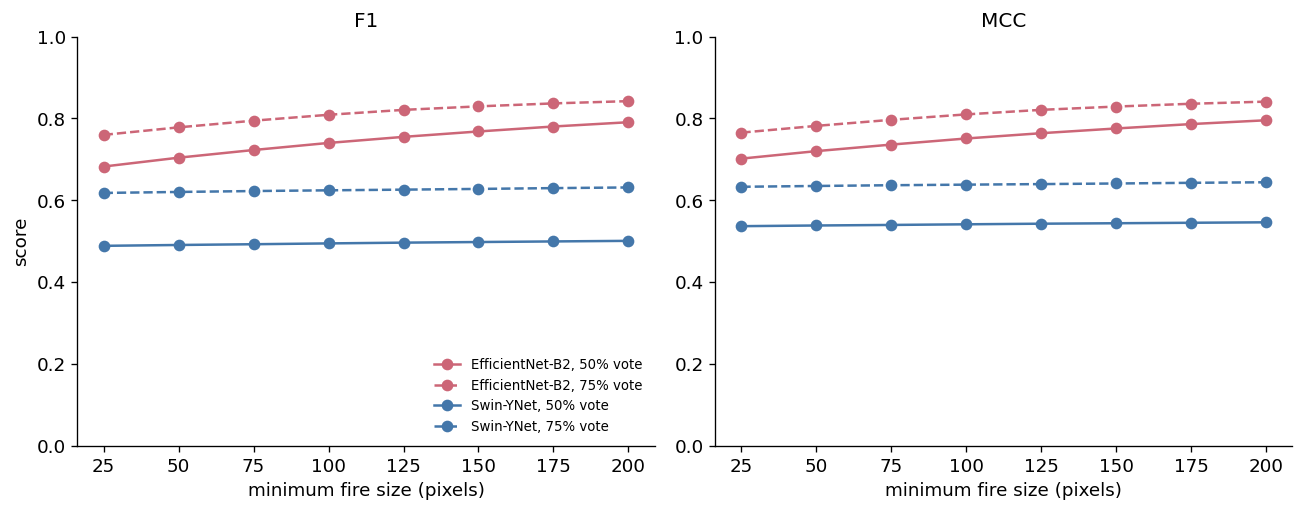

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True)
for ax, metric in zip(axes, ["F1", "MCC"]):
    for (mdl, vp), g in size_stats.groupby(["model", "vote_pct"]):
        ax.plot(g["min_size_px"], g[metric], "o", linestyle=VOTE_LS[vp],
                color=MODEL_COLOR[mdl], label=f"{MODEL_LABEL[mdl]}, {vp}% vote")
    ax.set_title(metric); ax.set_xlabel("minimum fire size (pixels)")
    ax.set_xticks(THRESHOLDS); ax.set_ylim(0, 1)
axes[0].set_ylabel("score"); axes[0].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

*Observation.* EfficientNet stays above Swin-YNet, and within each model the
75 percent vote (dashed) starts higher than the 50 percent vote (solid). Raising
the minimum size lifts every curve, so the size filter still helps even after the
vote has removed some false alarms.

#### 2.1.3 Precision and recall

**Objective.** Show the trade directly. **Assumption.** Same lines as above.

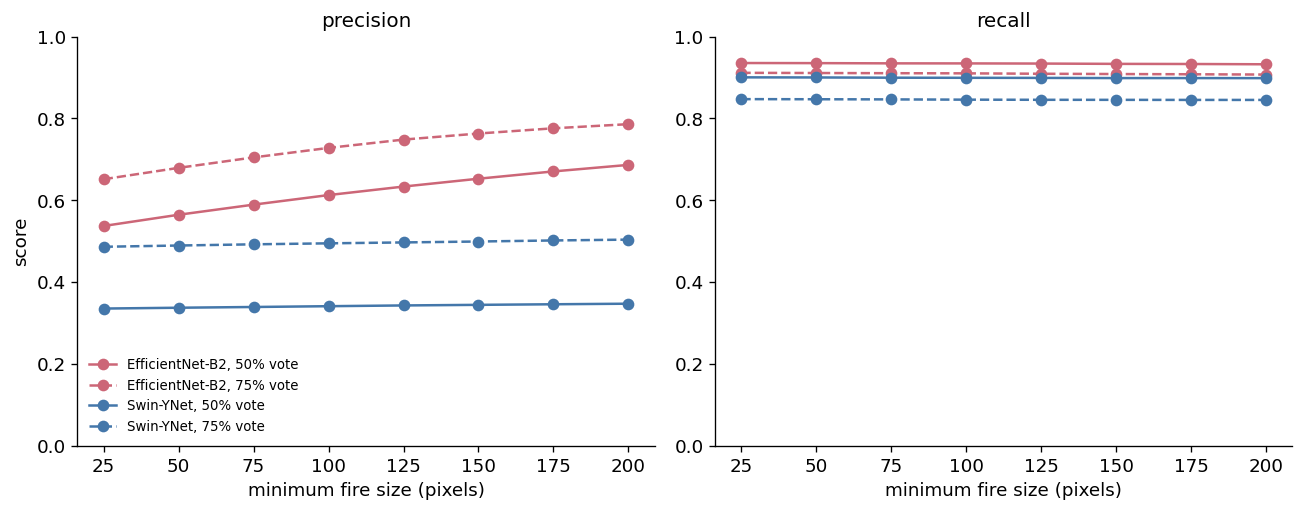

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True)
for ax, metric in zip(axes, ["precision", "recall"]):
    for (mdl, vp), g in size_stats.groupby(["model", "vote_pct"]):
        ax.plot(g["min_size_px"], g[metric], "o", linestyle=VOTE_LS[vp],
                color=MODEL_COLOR[mdl], label=f"{MODEL_LABEL[mdl]}, {vp}% vote")
    ax.set_title(metric); ax.set_xlabel("minimum fire size (pixels)")
    ax.set_xticks(THRESHOLDS); ax.set_ylim(0, 1)
axes[0].set_ylabel("score"); axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

*Observation.* Precision climbs as small patches are dropped, while recall
falls only gently, since real fires are large and survive the filter. The trade is
favourable for both vote settings.

#### 2.1.4 Burned area versus the threshold

**Objective.** Track the total flagged area against the actual fire. **Assumption.**
Burned area is the flagged area on the scored pixels.

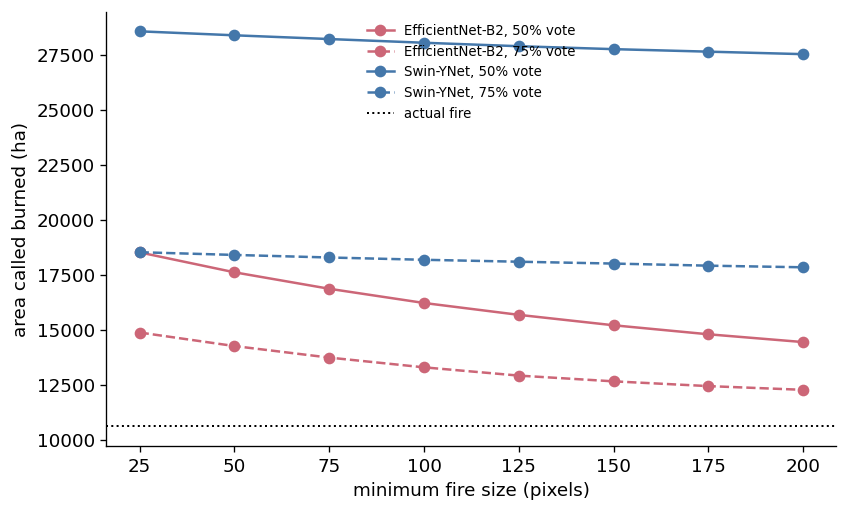

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for (mdl, vp), g in size_stats.groupby(["model", "vote_pct"]):
    ax.plot(g["min_size_px"], g["burned_ha"], "o", linestyle=VOTE_LS[vp],
            color=MODEL_COLOR[mdl], label=f"{MODEL_LABEL[mdl]}, {vp}% vote")
ax.axhline(t.sum()*PIX_HA, ls=":", color="black", lw=1.2, label="actual fire")
ax.set_xlabel("minimum fire size (pixels)"); ax.set_ylabel("area called burned (ha)")
ax.set_xticks(THRESHOLDS); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

*Observation.* The flagged area falls toward the actual fire line as the
filter tightens, and the 75 percent vote starts closer to it than the 50 percent
vote.

## 3. Spatial view

This section maps the effect on the ground at the strict (75 percent) vote, so the
reader can see which patches the size filter removes.

### 3.1 Where the filter cleans up

Agreement maps (violet = true positive, red = false positive, blue = false
negative) at three minimum sizes, for the 75 percent vote.

#### 3.1.1 Agreement maps at selected minimum sizes

**Objective.** Map true and false positives at minimum sizes of 25, 100 and 200
pixels, for both models, at 50% overlap and a 75 percent vote. **Assumption.** Maps
are shrunk for display, Portugal boundary drawn.

In [8]:
SHOW = [25, 100, 200]
MAP_VOTE = 75

def pool_or(a, k=12):
    H, W = (a.shape[0]//k)*k, (a.shape[1]//k)*k
    return a[:H, :W].reshape(H//k, k, W//k, k).max(axis=(1, 3))

def confusion_rgb(mdl, vp, ms):
    p = filtered_pred(mdl, vp, ms)
    TP, FP, FN = pool_or(p & t), pool_or(p & ~t), pool_or(~p & t)
    img = np.ones(TP.shape + (3,))
    for m, c in [(FN, C_MISS), (FP, C_FALSE), (TP, C_AGREE)]:
        img[m] = mcolors.to_rgb(c)
    return img

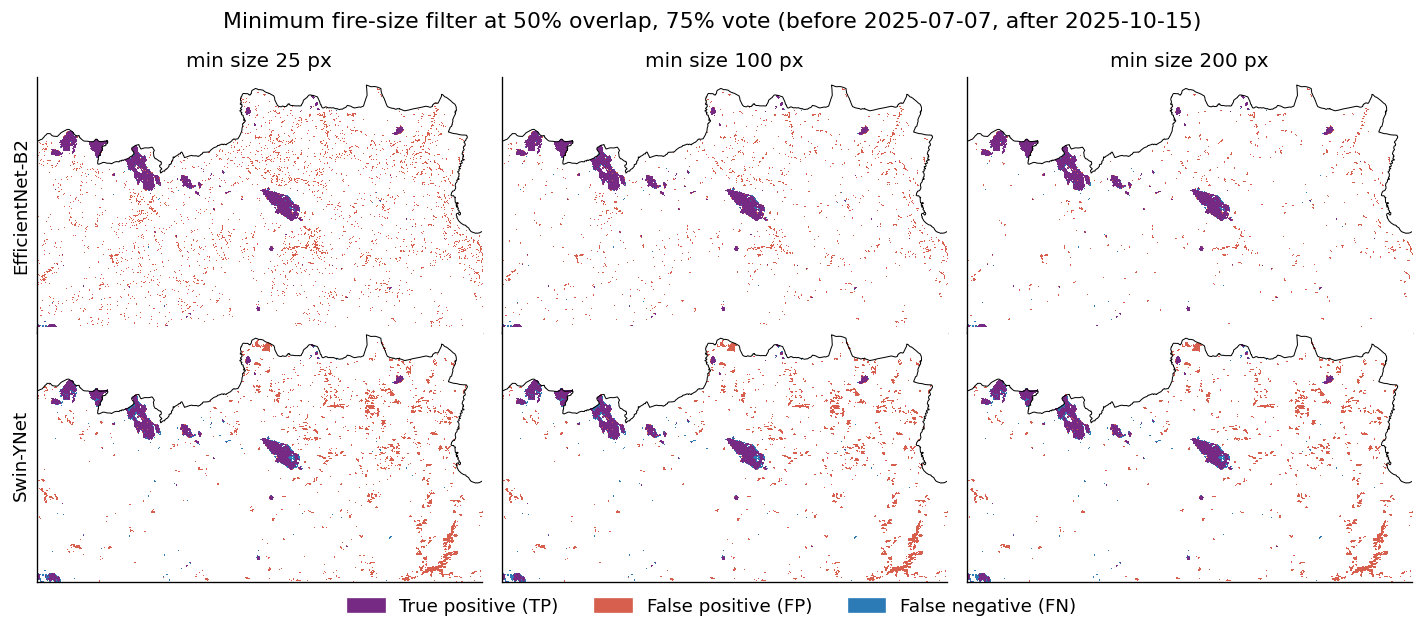

In [9]:
fig, axes = plt.subplots(len(MODELS), len(SHOW), figsize=(4*len(SHOW), 2.6*len(MODELS)))
axes = np.atleast_2d(axes)
for i, mdl in enumerate(MODELS):
    for j, ms in enumerate(SHOW):
        ax = axes[i, j]
        ax.imshow(confusion_rgb(mdl, MAP_VOTE, ms), extent=EXTENT, origin="upper", interpolation="nearest")
        PT.boundary.plot(ax=ax, color="black", linewidth=0.6)
        ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3])
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0: ax.set_title(f"min size {ms} px")
        if j == 0: ax.set_ylabel(MODEL_LABEL[mdl])
handles = [mpatches.Patch(color=C_AGREE, label="True positive (TP)"),
           mpatches.Patch(color=C_FALSE, label="False positive (FP)"),
           mpatches.Patch(color=C_MISS,  label="False negative (FN)")]
fig.suptitle(f"Minimum fire-size filter at 50% overlap, {MAP_VOTE}% vote "
             f"(before {BEFORE}, after {AFTER})", y=0.99)
fig.legend(handles=handles, loc="lower center", ncol=3)
plt.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

*Observation.* Left to right, the red false positives thin out while the
violet fires stay. For EfficientNet (top) the removed patches are scattered specks;
for Swin-YNet (bottom) some larger blobs remain that the size filter cannot reach.

## 4. Summary

On the 50% overlap maps, raising the minimum fire size still helps after the vote
has already filtered some false alarms. F1 and MCC rise for every model and vote
threshold as the minimum goes from 25 to 200 pixels, precision climbs, and recall
falls only gently because real fires are far larger than the threshold. The strict
75 percent vote starts ahead of the plain 50 percent vote and stays ahead.
EfficientNet-B2 leads Swin-YNet throughout. The size filter helps EfficientNet more,
because its remaining false alarms are small scattered specks, while some of
Swin-YNet's are large blobs the filter cannot remove. Read the best minimum off the
F1 and MCC curves: take the value where the gain flattens, beyond which you only
start losing real fire. Confirm the EfficientNet band order with the model author
before treating these numbers as final.